# Integrative Analysis of Breast Cancer Susceptibility Loci and Tumor Immune Programs Reveals Immune-Associated Candidate Genes in Triple-Negative Breast Cancer

---

## Module: Notebook 9 - Multi-Scale Risk-Immune Correlation

### Objective

This notebook investigates whether prioritized breast cancer susceptibility genes are associated with immune pathway activity within the TNBC cohort.

Specifically, expression levels of genes identified through the integration of GWAS susceptibility loci and TNBC differential expression analysis are correlated with patient-specific immune pathway activity estimated using ssGSEA.

By integrating germline susceptibility with tumor immune phenotypes, this analysis aims to identify candidate genes that may contribute to immune regulation in triple-negative breast cancer.

In [1]:
import os
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Processed Datasets

Load the datasets generated in previous notebooks:

- normalized RNA-seq expression matrix
- prioritized GWAS–TNBC overlap genes
- ssGSEA immune pathway scores
- clinical metadata

In [2]:
counts_raw = pd.read_csv("../data/rna_seq/brca_counts_cleaned.csv", index_col=0)
overlapping_df = pd.read_csv("../results/tables/overlapping_genes.csv", index_col=0)
ssgsea_scores = pd.read_csv("../results/tables/brca_ssgsea_immune_scores.csv", index_col=0)
metadata = pd.read_csv("../data/rna_seq/brca_clinical_cleaned.csv", index_col=0)

### 2. Normalize Gene Expression

RNA-seq counts are converted to log₂(CPM + 1) values to reduce sequencing depth effects while preserving relative expression differences across patients.

In [3]:
cpm = counts_raw.div(counts_raw.sum(axis=0), axis=1) * 1e6
counts_normalized = np.log2(cpm + 1)

### 3. Define Prioritized Candidate Genes

Retrieve the genes identified previously through integration of:

- breast cancer GWAS susceptibility loci
- TNBC differential expression analysis

These genes represent high-priority candidates linking inherited susceptibility with tumor-specific transcriptional alterations.

In [4]:
overlapping_genes = overlapping_df.index.tolist()

### 4. Restrict Analysis to the TNBC Cohort

Correlation analysis is performed exclusively within patients diagnosed with triple-negative breast cancer.

Restricting the analysis to TNBC enables evaluation of gene–immune relationships within the disease subtype of interest while minimizing heterogeneity introduced by other breast cancer subtypes.

In [5]:
tnbc_patients = metadata[metadata['condition_group'] == 'TNBC'].index.intersection(ssgsea_scores.index)

expr_subset = counts_normalized.loc[overlapping_genes, tnbc_patients].T
ssgsea_subset = ssgsea_scores.loc[tnbc_patients]

### 5. Compute Gene–Immune Correlations

Spearman rank correlation is calculated between expression of each prioritized candidate gene and enrichment scores for six immune-related Hallmark pathways.

Spearman correlation is a non-parametric statistic that measures monotonic associations without assuming normally distributed data, making it appropriate for transcriptomic analyses.

In [6]:
raw_results = []

for gene in overlapping_genes:
    for pathway in ssgsea_subset.columns:
        rho, p_val = stats.spearmanr(expr_subset[gene], ssgsea_subset[pathway])
        raw_results.append({
            'Gene': gene,
            'Pathway': pathway,
            'Spearman_rho': rho,
            'Raw_p_value': p_val
        })

corr_df = pd.DataFrame(raw_results)

### 6. Correct for Multiple Hypothesis Testing

Because correlations are computed across multiple gene–pathway combinations, raw p-values are adjusted using the Benjamini–Hochberg False Discovery Rate (FDR) procedure.

This reduces false-positive discoveries while maintaining statistical power.

In [7]:
reject, fdr_pvals, _, _ = multipletests(
    pvals=corr_df['Raw_p_value'],
    alpha=0.05,
    method='fdr_bh'
)

corr_df['FDR_Adjusted_p_value'] = fdr_pvals
corr_df['Is_Significant_FDR_05'] = reject

### 7. Export Correlation Statistics

Save the complete correlation results, including:

- Spearman correlation coefficients (ρ)
- raw p-values
- FDR-adjusted p-values
- statistical significance

These tables provide a reproducible record of the statistical analysis.

In [8]:
corr_matrix = corr_df.pivot(index='Gene', columns='Pathway', values='Spearman_rho').loc[overlapping_genes]
fdr_matrix = corr_df.pivot(index='Gene', columns='Pathway', values='FDR_Adjusted_p_value').loc[overlapping_genes]

corr_df.to_csv("../results/tables/gwas_immune_global_correlation_statistics.csv", index=False)
corr_matrix.to_csv("../results/tables/gwas_immune_spearman_rho.csv")
fdr_matrix.to_csv("../results/tables/gwas_immune_spearman_fdrpvalues.csv")

### 8. Visualize Gene–Immune Associations

Generate a heatmap summarizing correlations between prioritized susceptibility genes and immune pathway activity.

Correlation coefficients are annotated within each cell, while statistically significant associations after FDR correction are highlighted using asterisks:

- **FDR < 0.05**
- **FDR < 0.01**

This visualization facilitates identification of genes showing coordinated immune-associated expression patterns.

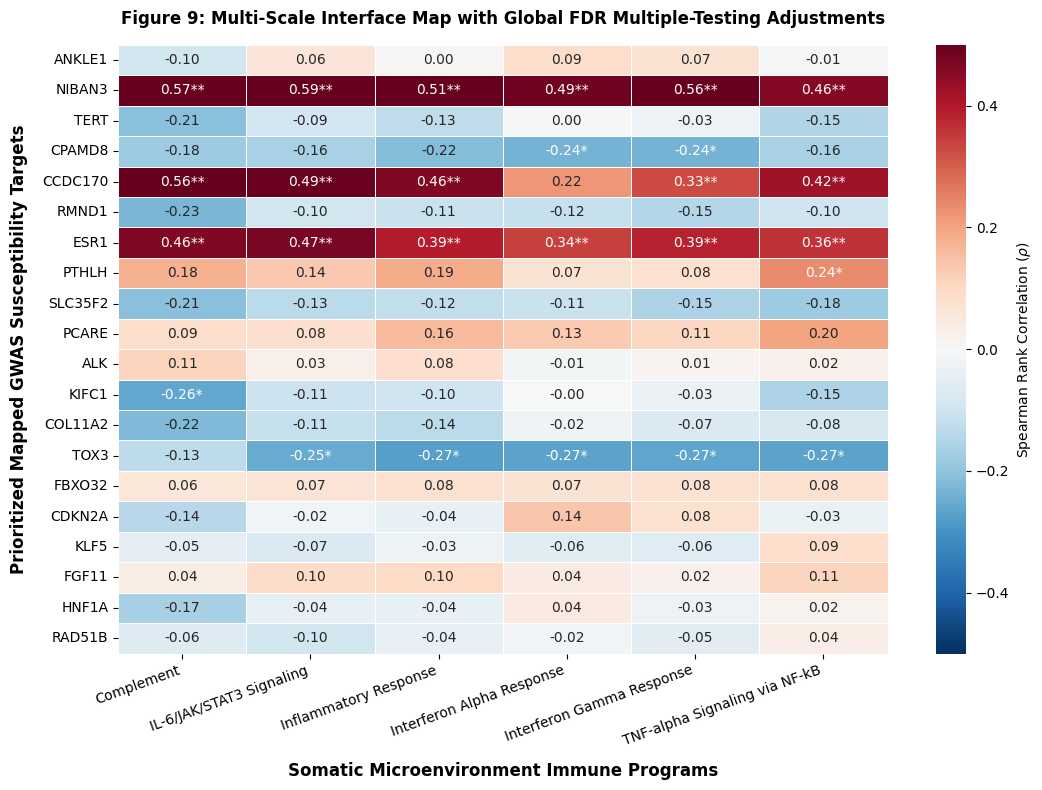

In [9]:
fig, ax = plt.subplots(figsize=(11, 8))

annotation_labels = corr_matrix.copy().astype(str)
for gene in overlapping_genes:
    for pathway in ssgsea_subset.columns:
        padj = fdr_matrix.loc[gene, pathway]
        rho = corr_matrix.loc[gene, pathway]
        if padj < 0.01:
            annotation_labels.loc[gene, pathway] = f"{rho:.2f}**"
        elif padj < 0.05:
            annotation_labels.loc[gene, pathway] = f"{rho:.2f}*"
        else:
            annotation_labels.loc[gene, pathway] = f"{rho:.2f}"

sns.heatmap(
    corr_matrix,
    cmap='RdBu_r',
    vmax=0.5,
    vmin=-0.5,
    center=0,
    annot=annotation_labels.values,
    fmt="",
    linewidths=0.7,
    cbar_kws={'label': "Spearman Rank Correlation ($\\rho$)"},
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=10)
ax.set_xlabel('Somatic Microenvironment Immune Programs', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Prioritized Mapped GWAS Susceptibility Targets', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Figure 9: Multi-Scale Interface Map with Global FDR Multiple-Testing Adjustments', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('../results/figures/gwas_immune_correlation_heatmap.png', dpi=300, bbox_inches='tight')

### Interpretation of the Multi-Scale Risk–Immune Correlation Heatmap

The correlation heatmap reveals that the majority of prioritized GWAS-associated candidate genes exhibit weak or inconsistent relationships with immune pathway activity within the TNBC cohort. However, a small subset of genes demonstrates coordinated associations across multiple immune programs, suggesting potential involvement in the regulation of the tumor immune microenvironment.

Among these, NIBAN3 displays consistently strong positive correlations with all six Hallmark immune pathways, including the Complement, Interferon Alpha Response, Interferon Gamma Response, IL-6/JAK/STAT3 Signaling, Inflammatory Response, and TNF-α Signaling via NF-κB signatures. These associations remain statistically significant following FDR correction, indicating that higher NIBAN3 expression is associated with increased immune pathway activity across TNBC tumors.

Similarly, ESR1 exhibits strong positive correlations with all six immune signatures, while CCDC170 shows significant positive associations with most immune pathways. The concordant behavior of these genes across multiple inflammatory and immune signaling programs suggests that they may participate in coordinated biological processes linking inherited breast cancer susceptibility with tumor immune regulation.

In contrast, TOX3 demonstrates consistent negative correlations with several immune pathways, indicating that increased TOX3 expression is associated with reduced immune pathway enrichment within TNBC tumors. This inverse relationship suggests that TOX3 may reflect an alternative transcriptional program or a comparatively less inflamed tumor microenvironment, although further experimental validation is required to establish its biological role.

Overall, these findings identify NIBAN3, ESR1, CCDC170, and TOX3 as the most prominent immune-associated candidates among the prioritized susceptibility genes. By integrating germline genetic risk with tumor transcriptomic and immune profiling data, this analysis refines a broad list of breast cancer susceptibility genes into a smaller group of biologically relevant candidates for future mechanistic and functional investigation.

### Notebook Summary

In this notebook, we investigated the relationship between prioritized breast cancer susceptibility genes and immune pathway activity within the TNBC cohort.

Major outcomes include:

Integrated normalized gene expression profiles with patient-specific ssGSEA immune enrichment scores.
Computed Spearman rank correlations between prioritized GWAS-associated candidate genes and six Hallmark immune pathways.
Applied Benjamini–Hochberg false discovery rate (FDR) correction to account for multiple hypothesis testing.
Visualized the gene–immune association landscape using a correlation heatmap annotated with statistical significance.
Identified NIBAN3, ESR1, and CCDC170 as genes exhibiting significant positive correlations with multiple immune pathways, while TOX3 demonstrated significant negative associations with several immune programs.

Overall, this analysis identified a subset of breast cancer susceptibility genes whose expression is closely associated with immune pathway activity in TNBC. These findings provide evidence that inherited genetic susceptibility and the tumor immune microenvironment may converge on common biological mechanisms, thereby prioritizing candidate genes for future functional and mechanistic studies.